In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr, zscore
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

from google.colab import drive

In [ ]:
drive.mount('/content/drive')
tracks = pd.read_csv('/content/drive/My Drive/CSC 380/spotify_data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
display(tracks)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


**Find how popularity correlates to every other numerical attribute**
---

In [ ]:
attributes = ['duration_ms','danceability','energy','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','time_signature']
pop_corr = {}
for att in attributes:
  pop_corr[att] = pearsonr(tracks[att], tracks['popularity'])

pop_corr

{'duration_ms': PearsonRResult(statistic=-0.00710120861970473, pvalue=0.01650071700496177),
 'danceability': PearsonRResult(statistic=0.03544813475138592, pvalue=4.963399462864344e-33),
 'energy': PearsonRResult(statistic=0.0010561362996984666, pvalue=0.7213996288715054),
 'loudness': PearsonRResult(statistic=0.050423036100497774, pvalue=4.484650120611793e-65),
 'mode': PearsonRResult(statistic=-0.013930786753107837, pvalue=2.5542396979524203e-06),
 'speechiness': PearsonRResult(statistic=-0.044926549261586374, pvalue=5.0649814412514124e-52),
 'acousticness': PearsonRResult(statistic=-0.025472412568363342, pvalue=7.849077309396664e-18),
 'instrumentalness': PearsonRResult(statistic=-0.0951392034446643, pvalue=2.0477886443460196e-227),
 'liveness': PearsonRResult(statistic=-0.00538715383159304, pvalue=0.06892581309773012),
 'valence': PearsonRResult(statistic=-0.04053429465994621, pvalue=1.1423936698305758e-42),
 'tempo': PearsonRResult(statistic=0.013204659932994899, pvalue=8.251525499

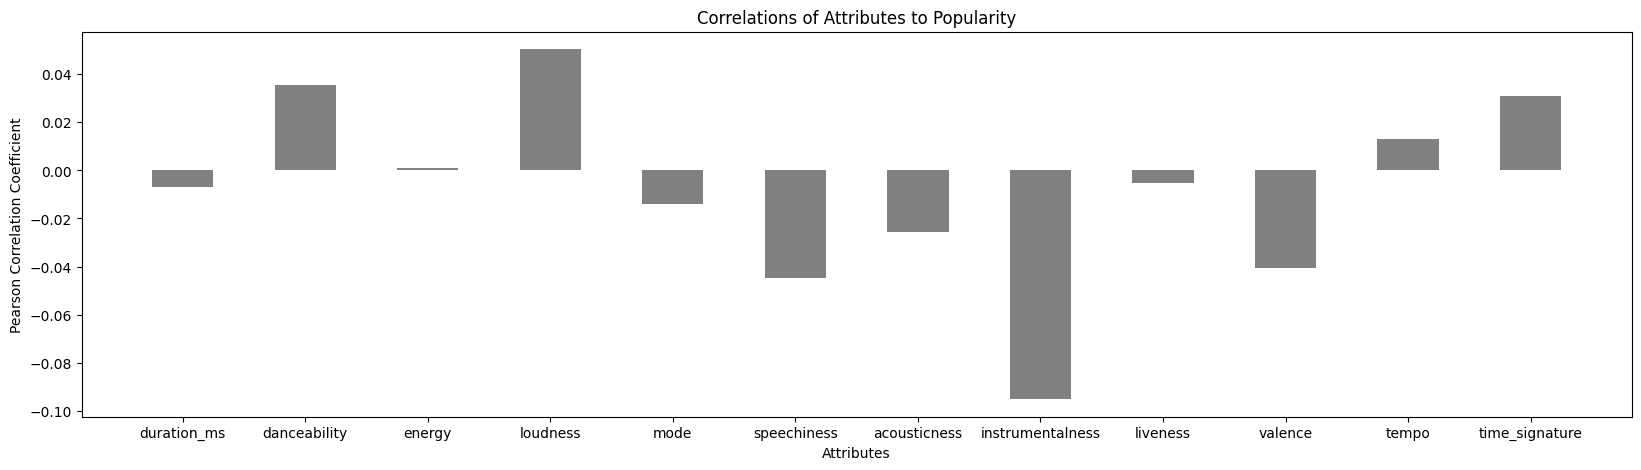

In [ ]:
vals = []
for i in pop_corr.values():
  vals.append(i[0])

fig = plt.figure(figsize = (20, 5))
plt.bar(pop_corr.keys(), vals, color ='gray', width = 0.5)

plt.xlabel("Attributes")
plt.ylabel("Pearson Correlation Coefficient")
plt.title("Correlations of Attributes to Popularity")
plt.show()

Using Pearson's Correlation Coefficient, I can conclude that the dataset is too large and diverse so that any correlation coefficients are not high at all, and almost every p-value implies significance on the correlations.

The greatest correlations in order: Loudness, Danceability, Time Signature, Tempo

Lowest correlations: Instrumentalness, Speechiness, Valence, Acousticness

I can not conclude significance from this data

In [ ]:
pop_corr_spearman = {}
for att in attributes:
  pop_corr_spearman[att] = spearmanr(tracks[att], tracks['popularity'])

pop_corr_spearman

{'duration_ms': SignificanceResult(statistic=0.02822655660892456, pvalue=1.5401889324619135e-21),
 'danceability': SignificanceResult(statistic=0.026628490890970167, pvalue=2.4208970098997164e-19),
 'energy': SignificanceResult(statistic=-0.023513149268771617, pvalue=2.0224077925110772e-15),
 'loudness': SignificanceResult(statistic=0.03517833368889887, pvalue=1.483671432046771e-32),
 'mode': SignificanceResult(statistic=-0.014501468548976607, pvalue=9.757697801470698e-07),
 'speechiness': SignificanceResult(statistic=-0.06787217704989643, pvalue=1.7511226310189415e-116),
 'acousticness': SignificanceResult(statistic=0.008399165149659332, pvalue=0.0045696255250203075),
 'instrumentalness': SignificanceResult(statistic=-0.0784535393718372, pvalue=4.420316953395367e-155),
 'liveness': SignificanceResult(statistic=-0.008189075224840187, pvalue=0.0056928717865211455),
 'valence': SignificanceResult(statistic=-0.041901687426678866, pvalue=1.7718748016617968e-45),
 'tempo': SignificanceResul

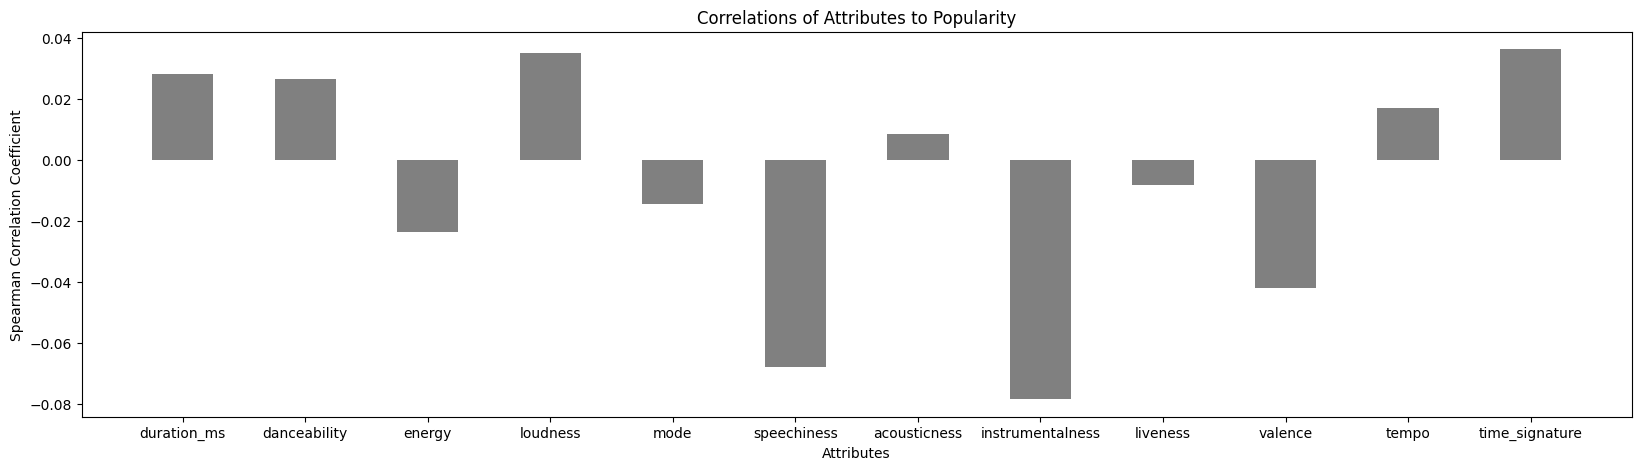

In [ ]:
vals = []
for i in pop_corr_spearman.values():
  vals.append(i[0])

fig = plt.figure(figsize = (20, 5))
plt.bar(pop_corr_spearman.keys(), vals, color ='gray', width = 0.5)

plt.xlabel("Attributes")
plt.ylabel("Spearman Correlation Coefficient")
plt.title("Correlations of Attributes to Popularity")
plt.show()

Using Spearman's Correlation Coefficient, I can conclude that the dataset is too large and diverse so that any correlation coefficients are not high at all, and every p-value implies significance on the correlations.

The greatest correlations in order: Time Signature, Loudness, Duration, Danceability

Lowest correlations: Instrumentalness, Speechiness, Valence, Acousticness

I can not conclude significance from this data

**Finding popularity correlation among non-numerical-based attributes based on mean**
---



In [ ]:
nn_atts = ['track_genre', 'artists', 'key', 'mode']
nn_pop_corr = {}
for att in nn_atts:
  nn_pop_corr[att] = tracks.groupby(att)['popularity'].mean().sort_values(ascending=False)

nn_pop_corr

{'track_genre': track_genre
 pop-film          59.283
 k-pop             56.896
 chill             53.651
 sad               52.379
 grunge            49.594
                    ...  
 chicago-house     12.339
 detroit-techno    11.174
 latin              8.297
 romance            3.245
 iranian            2.210
 Name: popularity, Length: 114, dtype: float64,
 'artists': artists
 Sam Smith;Kim Petras                                                 100.0
 Bizarrap;Quevedo                                                      99.0
 Manuel Turizo                                                         98.0
 Bad Bunny;Chencho Corleone                                            97.0
 Bad Bunny;Bomba Estéreo                                               94.5
                                                                      ...  
 Pyotr Ilyich Tchaikovsky;Martha Argerich;Nicolas Economou              0.0
 Pyotr Ilyich Tchaikovsky;Los Angeles Philharmonic;Gustavo Dudamel      0.0
 Kenny Che

**Distribution of a music genre's popularity**
---
Among the top 5 most popular genres




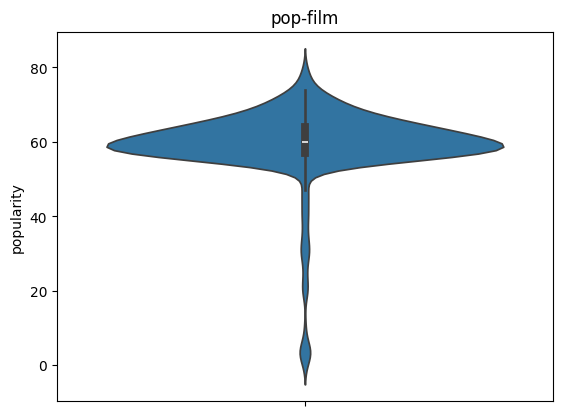

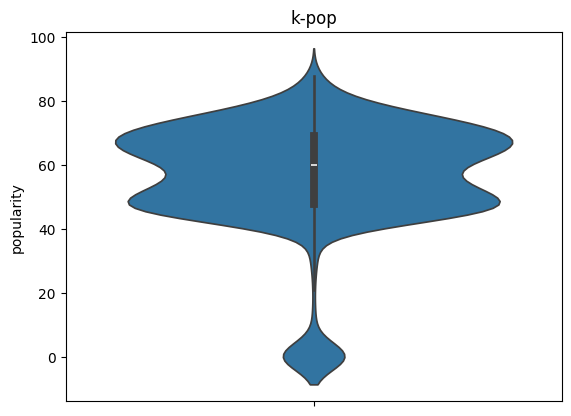

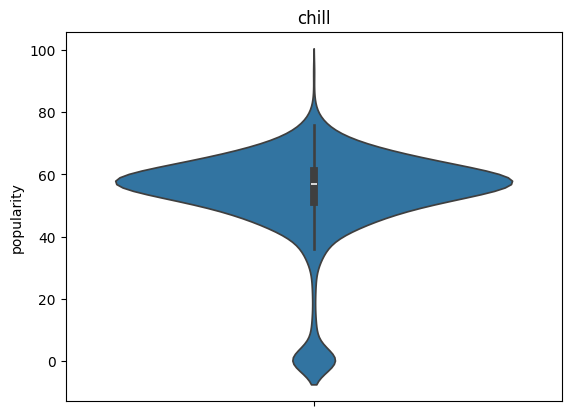

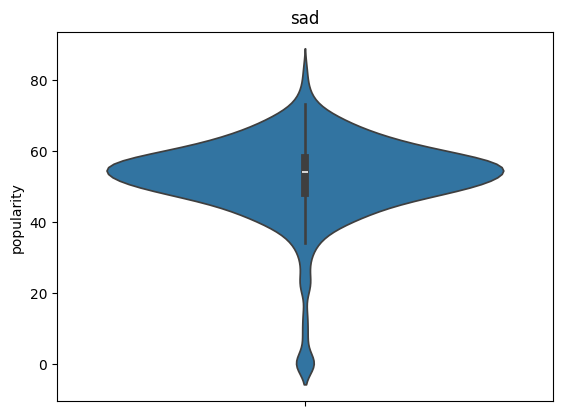

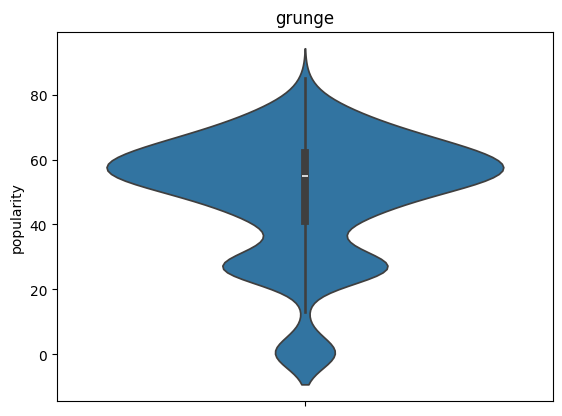

In [ ]:
genres = ['pop-film', 'k-pop', 'chill', 'sad', 'grunge']

for genre in genres:
  g_tracks = tracks['track_genre'].apply(lambda g: g == genre)
  plt.figure()
  plt.title(genre)
  sns.violinplot(y = tracks[g_tracks]['popularity'])

It appears that the distributions of the song genres are relatively concentrated around the mean, as expected. Since they are the most popular ones, it makes sense that the mean is high for all of them.

**Comparing the Top Genres**

In [ ]:
'''top10 = tracks.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)
top10 = ['pop-film','k-pop','chill','sad','grunge','indian','anime','emo','sertanejo','pop']
top10_vals = nn_pop_corr['track_genre'].head(10)

fig = plt.figure(figsize = (20, 5))
plt.bar(top10, top10_vals, color ='maroon', width = 0.5)

plt.xlabel("Top Genres")
plt.ylabel("Average Popularity")
plt.title("Average Popularity of Top Genres")
plt.show()'''

'top10 = tracks.groupby(\'track_genre\')[\'popularity\'].mean().sort_values(ascending=False).head(10)\ntop10 = [\'pop-film\',\'k-pop\',\'chill\',\'sad\',\'grunge\',\'indian\',\'anime\',\'emo\',\'sertanejo\',\'pop\']\ntop10_vals = nn_pop_corr[\'track_genre\'].head(10)\n\nfig = plt.figure(figsize = (20, 5))\nplt.bar(top10, top10_vals, color =\'maroon\', width = 0.5)\n\nplt.xlabel("Top Genres")\nplt.ylabel("Average Popularity")\nplt.title("Average Popularity of Top Genres")\nplt.show()'

**Repeating the same processes but with only the top 5,000 popular tracks**
---

In [ ]:
ptracks = tracks.sort_values(by='popularity', ascending=False).head(5000)

NameError: name 'tracks' is not defined

In [ ]:
pop_corr2 = {}
for att in attributes:
  pop_corr2[att] = pearsonr(ptracks[att], ptracks['popularity'])

pop_corr2

{'duration_ms': PearsonRResult(statistic=-0.061033559406838474, pvalue=1.569711273281237e-05),
 'danceability': PearsonRResult(statistic=0.14924858270262956, pvalue=2.6687403899784697e-26),
 'energy': PearsonRResult(statistic=0.02819700190068597, pvalue=0.046181897287179745),
 'loudness': PearsonRResult(statistic=0.0927820035233327, pvalue=4.923850941102045e-11),
 'mode': PearsonRResult(statistic=-0.04390016952002945, pvalue=0.00190323123869863),
 'speechiness': PearsonRResult(statistic=0.0528463971151841, pvalue=0.00018513430764603025),
 'acousticness': PearsonRResult(statistic=-0.08270925534824317, pvalue=4.71297000355781e-09),
 'instrumentalness': PearsonRResult(statistic=-0.05879066667983871, pvalue=3.1868468062243485e-05),
 'liveness': PearsonRResult(statistic=-0.013838079820613124, pvalue=0.32792488580760204),
 'valence': PearsonRResult(statistic=0.000915157284459613, pvalue=0.9484166639562238),
 'tempo': PearsonRResult(statistic=-0.0226587245579539, pvalue=0.10915144347354892),


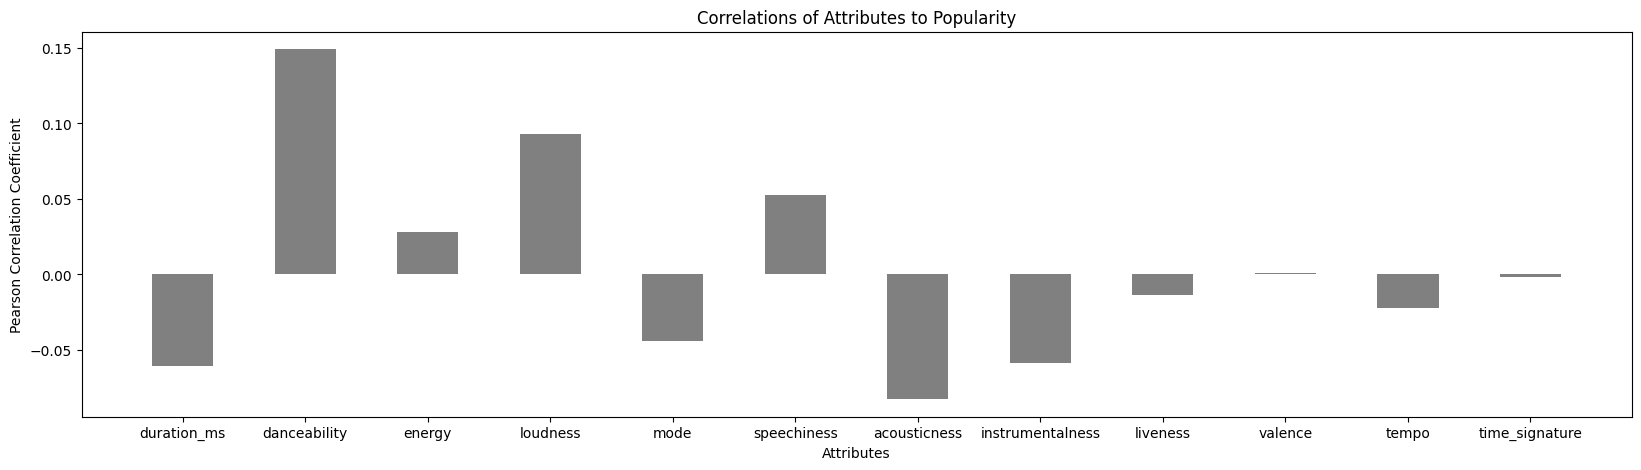

In [ ]:
vals = []
for i in pop_corr2.values():
  vals.append(i[0])

fig = plt.figure(figsize = (20, 5))
plt.bar(pop_corr.keys(), vals, color ='gray', width = 0.5)

plt.xlabel("Attributes")
plt.ylabel("Pearson Correlation Coefficient")
plt.title("Correlations of Attributes to Popularity")
plt.show()

In [ ]:
pop_corr_spearman2 = {}
for att in attributes:
  pop_corr_spearman2[att] = spearmanr(ptracks[att], ptracks['popularity'])

pop_corr_spearman2

{'duration_ms': SignificanceResult(statistic=-0.05001923871728616, pvalue=0.0004028270842061142),
 'danceability': SignificanceResult(statistic=0.1346944186216678, pvalue=1.11583871540942e-21),
 'energy': SignificanceResult(statistic=0.018674282757977438, pvalue=0.18674950796029915),
 'loudness': SignificanceResult(statistic=0.08787445042120015, pvalue=4.841695012806203e-10),
 'mode': SignificanceResult(statistic=-0.03581991660655556, pvalue=0.01130812300913871),
 'speechiness': SignificanceResult(statistic=0.06471978134055861, pvalue=4.648927998490598e-06),
 'acousticness': SignificanceResult(statistic=-0.06078960307968556, pvalue=1.6973962325280377e-05),
 'instrumentalness': SignificanceResult(statistic=-0.0448559989003962, pvalue=0.0015107953583439956),
 'liveness': SignificanceResult(statistic=-0.012304433989522535, pvalue=0.38437131026181504),
 'valence': SignificanceResult(statistic=0.022128595003866658, pvalue=0.11769355471059607),
 'tempo': SignificanceResult(statistic=-0.03053

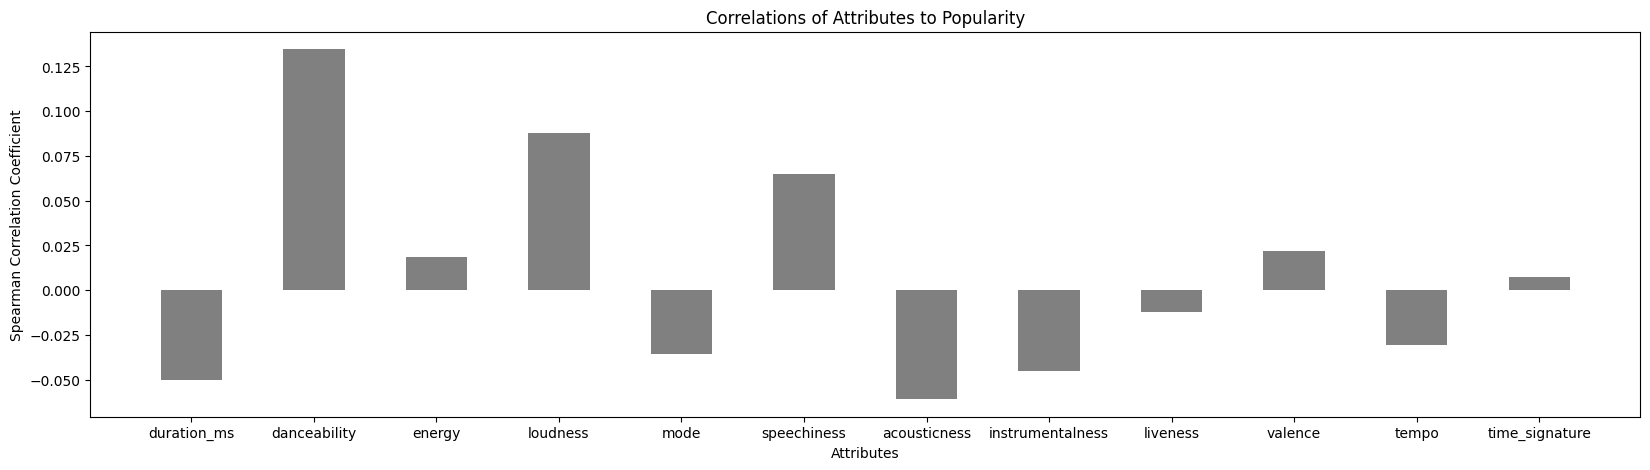

In [ ]:
vals = []
for i in pop_corr_spearman2.values():
  vals.append(i[0])

fig = plt.figure(figsize = (20, 5))
plt.bar(pop_corr_spearman.keys(), vals, color ='gray', width = 0.5)

plt.xlabel("Attributes")
plt.ylabel("Spearman Correlation Coefficient")
plt.title("Correlations of Attributes to Popularity")
plt.show()

In [ ]:
nn_pop_corr2 = {}
for att in nn_atts:
  nn_pop_corr2[att] = ptracks.groupby(att)['popularity'].mean().sort_values(ascending=False)

nn_pop_corr2

{'track_genre': track_genre
 club           85.000000
 brazil         82.000000
 latin          80.490196
 reggae         80.000000
 latino         79.820359
                  ...    
 mandopop       71.000000
 guitar         71.000000
 trip-hop       71.000000
 idm            70.000000
 world-music    70.000000
 Name: popularity, Length: 90, dtype: float64,
 'artists': artists
 Sam Smith;Kim Petras                          100.0
 Bizarrap;Quevedo                               99.0
 Manuel Turizo                                  98.0
 David Guetta;Bebe Rexha                        98.0
 Bad Bunny;Chencho Corleone                     97.0
                                               ...  
 Camille Saint-Saëns;Yo-Yo Ma;Kathryn Stott     70.0
 Vluestar                                       70.0
 K-391;Alan Walker;Tungevaag;Mangoo             70.0
 The Chainsmokers;Phoebe Ryan                   70.0
 Little Big Town                                70.0
 Name: popularity, Length: 1685, dty

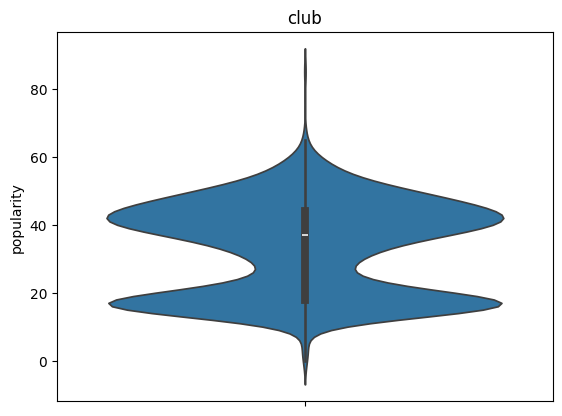

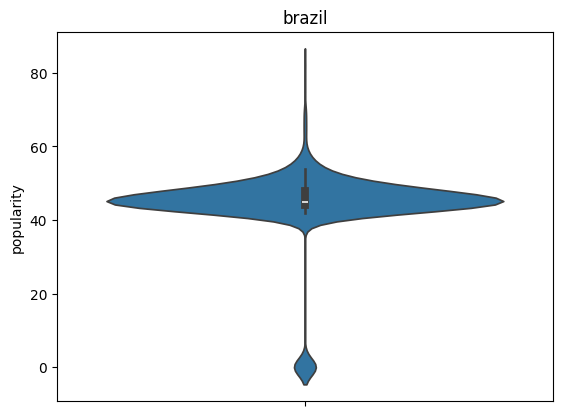

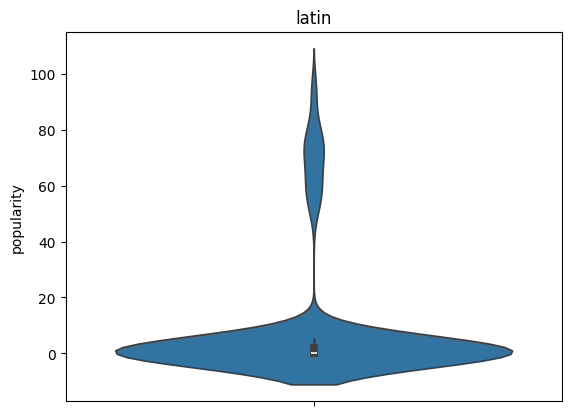

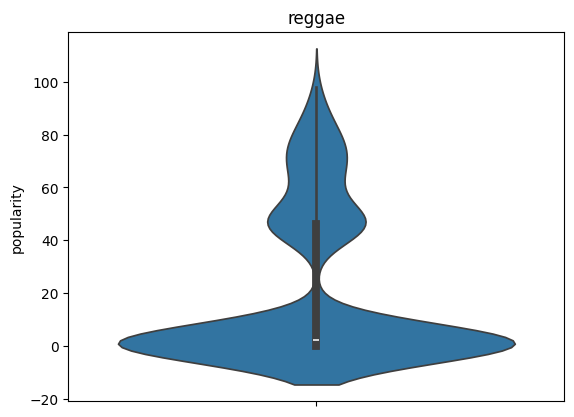

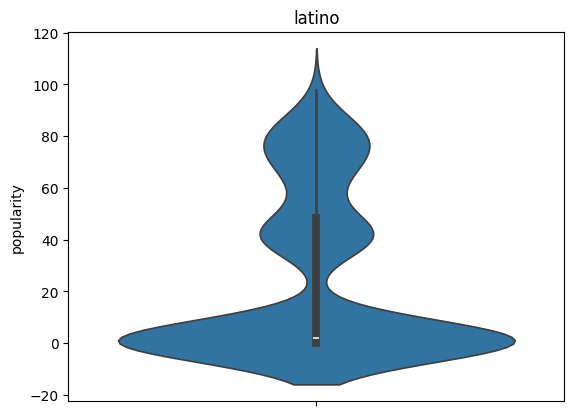

In [ ]:
genres = ['club', 'brazil', 'latin', 'reggae', 'latino']

for genre in genres:
  g_tracks = tracks['track_genre'].apply(lambda g: g == genre)
  plt.figure()
  plt.title(genre)
  sns.violinplot(y = tracks[g_tracks]['popularity'])

It appears that the distributions of the song genres this time are very spread out. For most of them, there appears to be almost two distinct groupings: one around the median and another one either higher or lower than the median. The ones that have groupings higher up make sense because those songs might've influenced the top genres of the top 5000 tracks. This would make the most sense for the 'latin' genre since most are concentrated near 0, but there are still many in the higher numbers.

**Compare the top genres in the original dataset vs the top genres in the top 5000 tracks**
---

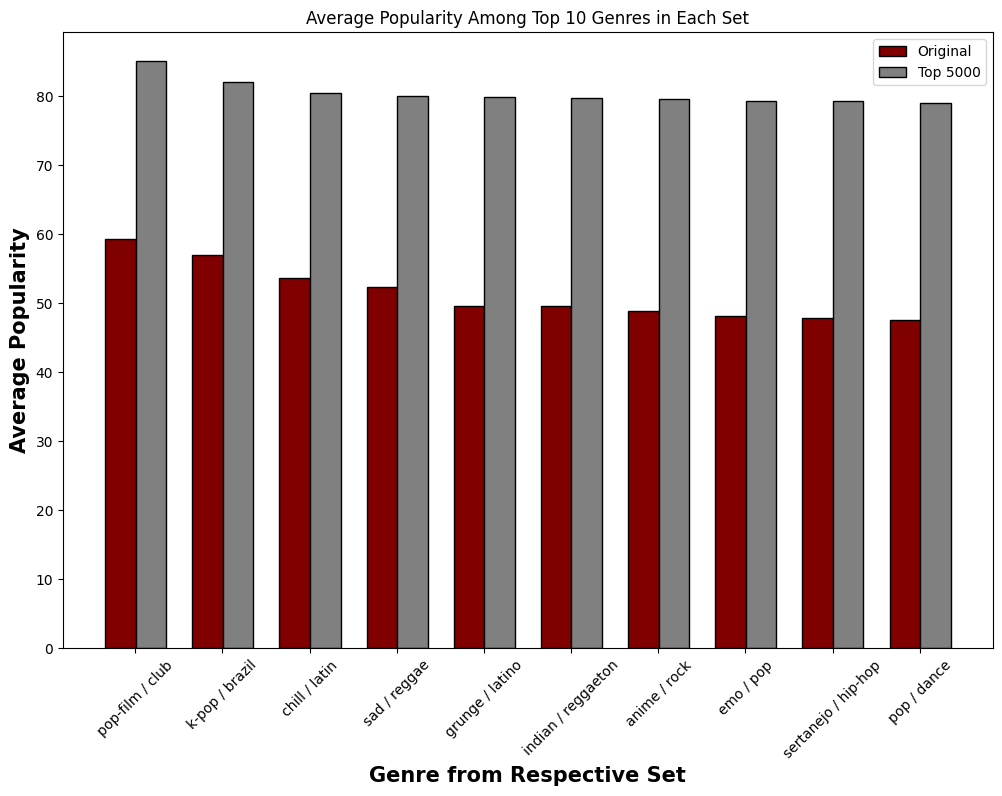

In [ ]:
top10 = ['pop-film','k-pop','chill','sad','grunge','indian','anime','emo','sertanejo','pop']
top10_2 = ['club','brazil','latin','reggae','latino','reggaeton','rock','pop','hip-hop','dance']
merged = []
for i in range(10):
  merged.append(top10[i] + " / " + top10_2[i])

# set width of bar
barWidth = 0.35
fig = plt.subplots(figsize =(12, 8))

# set height of bar
#top10_vals_og = zscore(nn_pop_corr['track_genre'].head(10))
#top10_vals_pop = zscore(nn_pop_corr2['track_genre'].head(10))
top10_vals_og = nn_pop_corr['track_genre'].head(10)
top10_vals_pop = nn_pop_corr2['track_genre'].head(10)

# Set position of bar on X axis
br1 = np.arange(10)
br2 = [x + barWidth for x in br1]

# Make the plot
plt.bar(br1, top10_vals_og, color ='maroon', width = barWidth,
        edgecolor ='black', label ='Original')
plt.bar(br2, top10_vals_pop, color ='gray', width = barWidth,
        edgecolor ='black', label ='Top 5000')

# Adding Xticks
plt.xlabel('Genre from Respective Set', fontweight ='bold', fontsize = 15)
plt.ylabel('Average Popularity', fontweight ='bold', fontsize = 15)
plt.xticks([r + barWidth - .18 for r in range(10)], merged, rotation=45)

plt.title('Average Popularity Among Top 10 Genres in Each Set')
plt.legend()
plt.show()

From this graph, we can see that the top genres in the entire set have less popularity on average compared to the top genres in the Top 5000 set. This makes complete sense because the whole set accounts for many songs that are not popular at all while the Top 5000 set has a guarantee to have songs that are popular. For the one coinciding genre, 'pop', we can see a difference of about 30 points.

Next steps:

*   K-means clustering to find subsets of tracks
*   Train models for each cluster. Forecast for a new point: Find its cluster and use the model trained for that cluster
*   Find belonging cluster using K-Nearest Neighbor
*   Other idea: use cosine similarity on any input song's features to find most similar songs. Can fine-tune features depending on a feature (i.e. popularity)
*   Maybe predict popularity using LR?





**Find the best value of n based on silhouette score for clustering**
---

**Split overall dataset into training and testing**

In [ ]:
from sklearn.model_selection import train_test_split

# numeric attributes
attributes = ['duration_ms','popularity','danceability','energy','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','time_signature']
X = tracks[attributes]
y = tracks[['popularity']]  # not used for next part
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

Credit to [sklearn](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py) for the silhouette test with nice graphs

CLustering is performed on X_test because of smaller sample size and the larger one takes very long. This test is done only to find best value of n clusters anyway.

In [ ]:
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

range_n_clusters = [2,3,4,8,10,20]

# normalize attribute numbers so they have equal weight
for att in attributes:
  X_test[[att]] = zscore(X_test[[att]])

for n_clusters in range_n_clusters:
    # Create a subplot for the silhouette plot and the clusterings
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-.1, 1])
    # For better spacing and visualization
    ax1.set_ylim([0, len(X_test) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, n_init="auto")
    cluster_labels = clusterer.fit_predict(X_test)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X_test, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X_test, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X_test.iloc[:, 0], X_test.iloc[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

NameError: name 'attributes' is not defined

**Using the results from the silhouette test (n=2), assign a cluster to each entry**

In [ ]:
# numerical attributes only (including popularity this time)
attributes = ['duration_ms', 'popularity', 'danceability','energy','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','time_signature']
X = tracks[attributes]
y = tracks[['popularity']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, n_init="auto").fit(X_train)
kmeans.predict(X_test)
labels = kmeans.labels_

clustered_tracks = X_train[attributes].copy()
clustered_tracks = clustered_tracks.assign(cluster=labels)
for i in range(n_clusters):
  print(f'Number of songs in cluster {i}: {clustered_tracks[clustered_tracks.cluster == i].shape[0]}')
display(clustered_tracks)

Number of songs in cluster 0: 70588
Number of songs in cluster 1: 14912


,duration_ms,popularity,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,cluster
15164,148361,60,0.766,0.426,-8.413,1,0.0573,0.812000,0.000000,0.1080,0.436,109.925,4,0
104225,239200,60,0.660,0.812,-4.193,1,0.0307,0.000264,0.000133,0.5660,0.773,124.031,4,0
66220,144303,16,0.580,0.974,-5.895,1,0.0658,0.014800,0.000032,0.4790,0.654,157.954,4,0
34743,236186,0,0.445,0.776,-4.492,1,0.0346,0.002520,0.007400,0.0981,0.403,118.379,4,0
84352,209453,57,0.455,0.502,-7.539,1,0.0493,0.699000,0.000156,0.0940,0.674,163.347,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24942,316974,7,0.695,0.837,-10.703,1,0.0482,0.006230,0.151000,0.1200,0.206,139.433,4,1
80667,315653,58,0.615,0.748,-8.788,0,0.0948,0.412000,0.000288,0.0621,0.505,135.071,4,1
109333,216026,59,0.545,0.953,-5.172,1,0.0441,0.000941,0.117000,0.2810,0.558,140.002,4,0
41398,254260,26,0.492,0.837,-5.926,0,0.0524,0.030700,0.270000,0.3600,0.338,135.005,4,0


In [ ]:
print(f"Correlations between cluster and each attribute:")
corr = {}
for att in attributes:
  corr[att] = spearmanr(clustered_tracks[att], clustered_tracks['cluster'])
  print(f"{att}: {spearmanr(clustered_tracks[att], clustered_tracks['cluster'])[0]}")

Correlations between cluster and each attribute:
duration_ms: 0.657245924072972
popularity: -0.030528815670435045
danceability: -0.08003090218822843
energy: 0.0051113635539570676
loudness: -0.10728172040526134
mode: -0.034878722670416605
speechiness: -0.044704102622215434
acousticness: -0.0824972387209567
instrumentalness: 0.21043347648358593
liveness: -0.03352477489193501
valence: -0.16930921535342736
tempo: 0.02523496792827082
time_signature: -0.007123397284457727


From this we can conclude that the clusterings are most based on a song's duration. Relatively, instrumentalness also plays a deciding role. However, overall, it might be better not to split the dataset into clusters and not have a different model for each cluster. The silhouette scores indicate that there are no clear clusterings in the dataset. (Scores closer to 1 indicate good clusterings, but most are close to 0 in this case).

However, we can try to use K-Nearest Neighbor to predict in which cluster a new song will end up in, and thus, it may have more similar attributes to other songs in the cluster. Here we will use n=20 (an arbitrary high number because there is no noticeable optimal n)

In [ ]:
# numerical attributes only (including popularity this time)
attributes = ['duration_ms', 'popularity', 'danceability','energy','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','time_signature']
X = tracks[attributes]

n_clusters = 20
kmeans = KMeans(n_clusters=n_clusters, n_init="auto").fit(X)
kmeans.predict(X)
labels = kmeans.labels_

clustered_tracks = tracks.copy()
clustered_tracks = clustered_tracks.assign(cluster=labels)
for i in range(n_clusters):
  print(f'Number of songs in cluster {i}: {clustered_tracks[clustered_tracks.cluster == i].shape[0]}')

Number of songs in cluster 0: 16837
Number of songs in cluster 1: 3559
Number of songs in cluster 2: 21
Number of songs in cluster 3: 5278
Number of songs in cluster 4: 9
Number of songs in cluster 5: 2187
Number of songs in cluster 6: 11281
Number of songs in cluster 7: 14922
Number of songs in cluster 8: 341
Number of songs in cluster 9: 9
Number of songs in cluster 10: 5285
Number of songs in cluster 11: 130
Number of songs in cluster 12: 1055
Number of songs in cluster 13: 48
Number of songs in cluster 14: 13
Number of songs in cluster 15: 10287
Number of songs in cluster 16: 8341
Number of songs in cluster 17: 16912
Number of songs in cluster 18: 14581
Number of songs in cluster 19: 2904


In [ ]:
y = clustered_tracks[['cluster']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [ ]:
cluster_predictions = knn.predict(X_test)
accuracy = knn.score(X_test, y_test)
print(f'The mean accuracy of the predictions is {accuracy}')

# Get the actual indices of songs in X_test for the recommendation algorithm
indices = {}
inds = X_test.index.values
for i in range(len(inds)):
  indices[inds[i]] = cluster_predictions[i]

The mean accuracy of the predictions is 0.9996140350877193


I surmise that the high accuracy is due to the large number of data points.
Now we can use the cluster_predictions list to predict the cluster a song belongs to, and then when recommending new songs, recommend ones within the same cluster,

**Use cosine similarity to find similarity between songs**
---
Cerdit to this [notebook](https://www.kaggle.com/code/akbareza/simple-music-recommendation-system#Similarity-Calculation) for the procedure

Get the one-hot encoding for song genres

In [ ]:
xtab_song = pd.crosstab(tracks['track_id'], tracks['track_genre'])
display(xtab_song.head(),len(xtab_song))

track_genre,acoustic,afrobeat,alt-rock,alternative,ambient,anime,black-metal,bluegrass,blues,brazil,...,spanish,study,swedish,synth-pop,tango,techno,trance,trip-hop,turkish,world-music
track_id,,,,,,,,,,,,,,,,,,,,,
0000vdREvCVMxbQTkS888c,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
000CC8EParg64OmTxVnZ0p,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
000Iz0K615UepwSJ5z2RE5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
000RDCYioLteXcutOjeweY,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
000qpdoc97IMTBvF8gwcpy,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


89741

In [ ]:
# Concatenate the encoded genre columns with the original dataframe and drop duplicates
cos_tracks = tracks.drop_duplicates('track_id')
cos_tracks = cos_tracks.sort_values('track_id')
cos_tracks = cos_tracks.reset_index(drop=True)
xtab_song.reset_index(inplace=True)
cos_tracks = pd.concat([cos_tracks, xtab_song], axis=1)
display(cos_tracks.head(),len(cos_tracks))

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,spanish,study,swedish,synth-pop,tango,techno,trance,trip-hop,turkish,world-music
0,39463,0000vdREvCVMxbQTkS888c,Rill,Lolly,Lolly,44,160725,True,0.910,0.374,...,0,0,0,0,0,0,0,0,0,0
1,17586,000CC8EParg64OmTxVnZ0p,Glee Cast,Glee Love Songs,It's All Coming Back To Me Now (Glee Cast Vers...,47,322933,False,0.269,0.516,...,0,0,0,0,0,0,0,0,0,0
2,73441,000Iz0K615UepwSJ5z2RE5,Paul Kalkbrenner;Pig&Dan,X,Böxig Leise - Pig & Dan Remix,22,515360,False,0.686,0.560,...,0,0,0,0,0,0,0,0,0,0
3,51365,000RDCYioLteXcutOjeweY,Jordan Sandhu,Teeje Week,Teeje Week,62,190203,False,0.679,0.770,...,0,0,0,0,0,0,0,0,0,0
4,73649,000qpdoc97IMTBvF8gwcpy,Paul Kalkbrenner,Zeit,Tief,19,331240,False,0.519,0.431,...,0,0,0,0,0,0,0,0,0,0


89741

In [ ]:
# Scale the values for each attribute so that they have equal weight when finding similarity
scaler = MinMaxScaler()
cos_tracks[attributes] = scaler.fit_transform(cos_tracks[attributes])

In [ ]:
# Select the relevant columns for computing item similarities
calc = attributes + list(xtab_song.drop(columns='track_id').columns)

# Take a small, random sample of the data because ~110,00 entries are too much for my PC to handle
sample = cos_tracks.sample(10000)
sample.reset_index(drop=True, inplace=True)
display(sample.head(5))
cosine_sim = cosine_similarity(sample[calc])

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,spanish,study,swedish,synth-pop,tango,techno,trance,trip-hop,turkish,world-music
0,28902,0rch4LXVKv8auzUU8TQh4x,Borgore;Miley Cyrus,#NEWGOREORDER,Decisions (feat. Miley Cyrus),0.49,0.037969,True,0.573604,0.9340,...,0,0,0,0,0,0,0,0,0,0
1,45345,1VIE8mzxCXp5Asn6aQF7oY,Cuco Sánchez,Tesoros De Colección,La Rosa de Oro,0.26,0.035909,False,0.556345,0.0935,...,0,0,0,0,0,0,0,0,0,0
2,43987,3iV11AiIEDIOVjKy3kgjld,Pantera,Far Beyond Driven,Becoming,0.56,0.035341,True,0.586802,0.8960,...,0,0,0,0,0,0,0,0,0,0
3,33540,3vvDp7R6SHDSJqhSOeCZL6,PXNDX,Poetics,Popurrí para Ti,0.38,0.037724,False,0.517766,0.8610,...,0,0,0,0,0,0,0,0,0,0
4,60758,3jumxkobNDisdRz27CxhOF,Rytikal,Private Jet Riddim,King Inna War,0.21,0.034981,True,0.807107,0.6000,...,0,0,0,0,0,0,0,0,0,0


# Song Recommendation Algorithms Using Cosine Similarity or KNN

**Cosine similarity**

In [ ]:
def get_song_recs(title, num_songs):
  # making a series of all the songs and their indices
  song_indices = pd.Series(sample.index, index=sample['track_name']).drop_duplicates()
  try:
    song_index = song_indices[title]
  except KeyError:
    print("This song is not available.")
    return

  # creating an array of tuples which contain each song index and its similarity to the given song
  sim_scores = []
  temp_index = 0
  for score in cosine_sim[song_index]:
    temp_tuple = (temp_index, score)
    sim_scores.append(temp_tuple)
    temp_index += 1

  sort_similars(sim_scores)
  sim_scores.pop(0) # remove self-score
  # appending the top similar songs to this array
  sim_scores_final = []
  for i in range(0, num_songs):
    sim_scores_final.append(sim_scores[i])

  # appending the top song indices and similarity scores to the respective arrays
  song_indices = []
  sim_scores_list = []
  for i in range(0, len(sim_scores_final)):
    song_indices.append(sim_scores_final[i][0])
    sim_scores_list.append(sim_scores_final[i][1])

  # creating a list of dictionaries to hold the information of the top recommended songs
  song_recs = sample[['track_name', 'artists']].iloc[song_indices]
  song_recs_list = song_recs.to_dict(orient='records')
  for i in range(0, len(song_recs_list)):
    song_recs_list[i]['similarity'] = sim_scores_list[i]
  return song_recs_list

# Sorting takes a long time because the dataset is still large and bubblesort is slow (sorry)
def sort_similars(array):
    n = len(array)
    for i in range(n-1):
        swapped = False
        for j in range(0, n-i-1):
            if array[j][1] < array[j+1][1]:
                swapped = True
                swap(array, j)
        if not swapped:
            return

def swap(array, index):
  array[index], array[index+1] = array[index+1], array[index]

def main():
  # Once again, because we are using a sample for similarity scores, many songs may not appear in the sample
  recommended_songs = get_song_recs("La Rosa de Oro", 5)
  if recommended_songs == None:
    return
  print("Recommended Songs:")
  print()

  for song_info in recommended_songs:
    print("Title:", song_info['track_name'])
    print("Artist(s):", song_info['artists'])
    print("Similarity:", song_info['similarity'])
    print()

main()

Recommended Songs:

Title: La Cama de Piedra
Artist(s): Cuco Sánchez
Similarity: 0.9965174050780186

Title: La chancla
Artist(s): Cuco Sánchez
Similarity: 0.9846113868350213

Title: Fragilidad
Artist(s): Cuarteto La Púa;Victoria Di Raimondo
Similarity: 0.984374190848901

Title: Que Si Te Quiero?, Júralo
Artist(s): Cuco Sánchez
Similarity: 0.981799488995094

Title: He Is The Only Reason
Artist(s): Maunalua
Similarity: 0.9814554177633663



**K-Nearest Neighbors**

In [ ]:
X_test

,duration_ms,popularity,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
90349,218093,35,0.512,0.2690,-17.237,1,0.0323,0.6080,0.000000,0.1690,0.5190,99.842,4
9718,249706,44,0.526,0.6730,-7.889,1,0.0358,0.3300,0.000027,0.0937,0.3330,81.063,4
51781,75000,57,0.724,0.6000,-12.024,0,0.4000,0.6360,0.000000,0.1330,0.7310,77.549,4
39290,684626,12,0.235,0.0975,-25.217,0,0.0345,0.9460,0.828000,0.1070,0.0361,145.033,3
25530,175515,34,0.650,0.8670,-4.832,0,0.1200,0.0102,0.000000,0.2260,0.7410,130.002,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79038,197146,0,0.262,0.6770,-5.645,1,0.0528,0.4470,0.000000,0.2050,0.3650,207.478,3
112094,149168,48,0.506,0.2330,-12.077,0,0.0276,0.9570,0.000028,0.1160,0.2750,88.080,4
24020,423052,15,0.887,0.6660,-10.997,0,0.0971,0.1160,0.769000,0.0872,0.3050,123.022,4
66740,192889,9,0.930,0.9620,-3.319,1,0.1180,0.1180,0.000000,0.0697,0.5080,111.995,4


In [ ]:
def get_recs_cluster(title, n):
  # Convert to set to easily check if it exists
  if title not in set(clustered_tracks['track_name']):
    print("Track not found")
    return

  # Get the requested song's cluster
  index = clustered_tracks.loc[clustered_tracks['track_name'] == title].index[0]

  # Note: since the cluster predictions were done on the test set, songs may often not be found
  try:
    cluster = indices[index]
  except KeyError:
    print('Song not assigned to a cluster score due to not being in X_test')
    return

  # Get all indices at which songs are in the same cluster
  same_cluster_indices = []
  for i in range(len(cluster_predictions)):
    if cluster_predictions[i] == cluster:
      same_cluster_indices.append(i)

  # Shuffle array for randomizing recommendations in the same cluster
  np.random.shuffle(same_cluster_indices)

  # Get song recommendations + make a new DataFrame with the given features
  feats = ['track_name', 'artists', 'track_genre']
  recs = pd.DataFrame(columns=feats)
  for i in range(n):
    rec = clustered_tracks[feats].iloc[[same_cluster_indices[i]]]
    recs = pd.concat([recs, rec])
    recs.reset_index()

  display(recs)

# Input a song name and number of recommendations
# Note that the song name must be in X_test
import random
random_index = random.choice(list(indices.keys()))
random_song = tracks['track_name'].iloc[random_index]

print(f'Recommendations for "{random_song}": ')
get_recs_cluster(random_song, 5)

Recommendations for "Dance": 


,track_name,artists,track_genre
25499,Mały Miś,DiscoBoys,disco
12439,愛得太遲,Leo Ku,cantopop
10613,Setting Sun,The Chemical Brothers,breakbeat
20858,no tears left to cry,Ariana Grande,dance
18842,The Biggest Ball of Twine In Minnesota,"""Weird Al"" Yankovic",comedy


# Conclusion
We can conclude that cosine similarity is very efficient at finding similar songs based on all the features that are involved in the calculation. We can see that the similarity scores for the recommended songs are all close to 1. Furthermore, clustering was not a great method to use on this dataset, given that none of the silhouette scores were very high.